### Development of the Metric Scoring of GB1 Dataset
To answer the RQ1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error

In [3]:
import metrics_gb1
metrics_gb1.main()

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
100%|██████████| 56022/56022 [16:48<00:00, 55.55it/s]   


In [4]:
df = pd.read_csv('results/gb1_generated_sequences_scored.csv')

### Calculate Surrogate Scores

In [5]:
# Random Forest
spearmanr_rf = spearmanr(df['oracle_score'], df['rf_prediction'])
mse_rf = mean_squared_error(df['oracle_score'], df['rf_prediction'])
bias_rf = (df['oracle_score'] - df['rf_prediction']).mean()
variance_rf = ((df['rf_prediction'] - df['rf_prediction'].mean()) ** 2).mean()

# MLP
spearmanr_mlp = spearmanr(df['oracle_score'], df['mlp_prediction'])
mse_mlp = mean_squared_error(df['oracle_score'], df['mlp_prediction'])
bias_mlp = (df['oracle_score'] - df['mlp_prediction']).mean()
variance_mlp = ((df['mlp_prediction'] - df['mlp_prediction'].mean()) ** 2).mean()

print(f"Random Forest - Spearman's rho: {spearmanr_rf.correlation:.4f}, MSE: {mse_rf:.4f}, Bias: {bias_rf:.4f}, Variance: {variance_rf:.4f}")
print(f"MLP - Spearman's rho: {spearmanr_mlp.correlation:.4f}, MSE: {mse_mlp:.4f}, Bias: {bias_mlp:.4f}, Variance: {variance_mlp:.4f}")


Random Forest - Spearman's rho: 0.3293, MSE: 23.0236, Bias: 3.8101, Variance: 1.3947
MLP - Spearman's rho: 0.6494, MSE: 14.6292, Bias: 2.9373, Variance: 6.1928


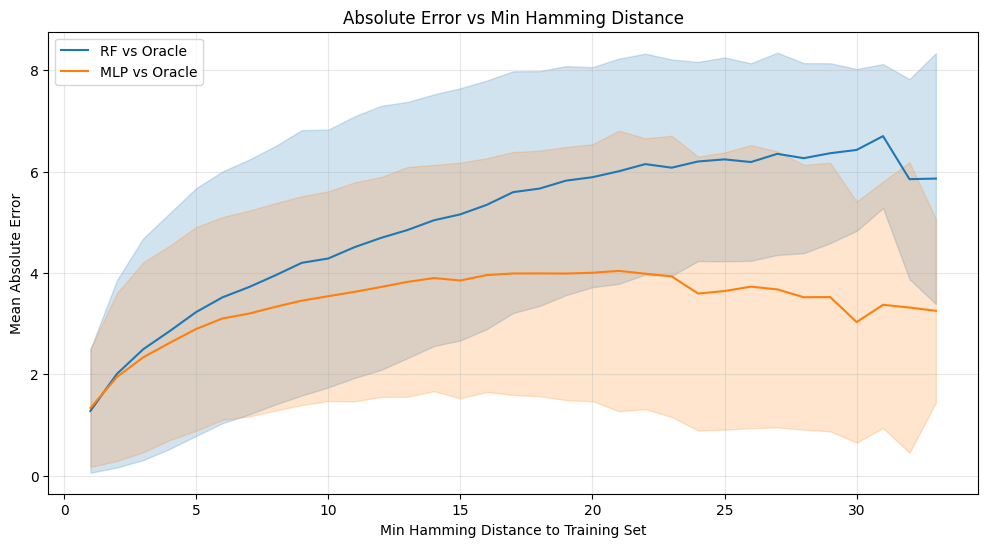

In [7]:
# Mean absolute error with shaded ±1 std, grouped by min Hamming distance

grouped = df.groupby('min_hamming_distance').agg(
    mean_error_rf=('oracle_score', lambda s: np.abs(s - df.loc[s.index, 'rf_prediction']).mean()),
    std_error_rf=('oracle_score', lambda s: np.abs(s - df.loc[s.index, 'rf_prediction']).std()),
    mean_error_mlp=('oracle_score', lambda s: np.abs(s - df.loc[s.index, 'mlp_prediction']).mean()),
    std_error_mlp=('oracle_score', lambda s: np.abs(s - df.loc[s.index, 'mlp_prediction']).std()),
).reset_index()

x = grouped['min_hamming_distance']

 
plt.figure(figsize=(12, 6))

plt.plot(x, grouped['mean_error_rf'], label=f'RF vs Oracle', color='tab:blue')
plt.fill_between(
    x,
    grouped['mean_error_rf'] - grouped['std_error_rf'],
    grouped['mean_error_rf'] + grouped['std_error_rf'],
    color='tab:blue',
    alpha=0.2
)

plt.plot(x, grouped['mean_error_mlp'], label=f'MLP vs Oracle', color='tab:orange')
plt.fill_between(
    x,
    grouped['mean_error_mlp'] - grouped['std_error_mlp'],
    grouped['mean_error_mlp'] + grouped['std_error_mlp'],
    color='tab:orange',
    alpha=0.2
)

plt.title('Absolute Error vs Min Hamming Distance')
plt.xlabel('Min Hamming Distance to Training Set')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Oracle Scores dev

In [ ]:
df['oracle_score'] = oracle.score_batch(df['sequence'].tolist())

plt.figure(figsize=(10, 6))
sns.histplot(df['oracle_score'], bins=20, kde=False)
plt.title('Distribution of Oracle Scores for Generated Sequences')
plt.xlabel('Oracle Score')
plt.ylabel('Frequency')
plt.show()

# plot distribution of real scores of df_train
plt.figure(figsize=(10, 6))
sns.histplot(df['binding_scores'], bins=20, kde=False)
plt.title('Distribution of Fitness Scores in GB1')
plt.xlabel('Fitness Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_generated['oracle_score_trained'], bins=20, kde=False, color='orange', label='Generated Sequences')
plt.title('Distribution of Trained Oracle Scores for Generated Sequences')
plt.xlabel('Trained Oracle Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
df.head(5)

### Oracle Training
- See Notion notebook. 
- Traind oracle scores are closer to the real scores, radom init scores have a gaussian distribution

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from assets.data_ops import encode_sequence as encode_sequence_idx, one_hot_encode_sequence

## Train the oracle on the whole dataset
oracle_trained = Oracle_GB1(L=1100, token_to_idx=token_to_idx, seed=42)
for param in oracle_trained.parameters():
    param.requires_grad = True
train_data = list(zip(df['sequence'].tolist(), df['binding_scores'].tolist()))

def build_oracle_dataset(train_data, token_to_idx):
    X = np.stack([
        one_hot_encode_sequence(
            encode_sequence_idx(seq, token_to_idx),
            num_tokens=len(token_to_idx)
        )
        for seq, _ in train_data
    ])
    y = np.asarray([score for _, score in train_data], dtype=np.float32)
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )

def train_oracle(oracle, train_data, token_to_idx, epochs=100):
    optimizer = torch.optim.Adam(oracle.parameters(), lr=0.001)
    train_dataset = build_oracle_dataset(train_data, token_to_idx)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    criterion = torch.nn.MSELoss()
    for epoch in range(epochs):
        oracle.train_epoch(train_loader, optimizer, criterion)

train_oracle(oracle_trained, train_data, token_to_idx, epochs=100)

df['oracle_score_trained'] = oracle_trained.score_batch(df['sequence'].tolist())
df_generated['oracle_score_trained'] = oracle_trained.score_batch(df_generated['sequence'].tolist())

plt.figure(figsize=(10, 6))
sns.histplot(df['oracle_score_trained'], bins=20, kde=False, color='blue', label='Real Sequences')
sns.histplot(df_generated['oracle_score_trained'], bins=20, kde=False, color='orange', label='Generated Sequences', alpha=0.7)
plt.title('Distribution of Trained Oracle Scores')
plt.xlabel('Trained Oracle Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()


